# TwinCar - EfficientNet-B0 v2 Evaluation Notebook

This notebook evaluates the trained **EfficientNet-B0 v2** model on the test set.

It calculates:

- accuracy
- top-5 accuracy
- precision
- recall
- F1-score
- balanced accuracy
- test loss
- make-level accuracy
- make + model accuracy
- readable confusion matrices
- confidence/error analysis
- misclassified examples
- inference speed benchmark

Use this notebook after running `03b_efficientnet_b0_v2.ipynb` and saving a model checkpoint.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import re
import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

try:
    from IPython.display import display
except Exception:
    display = print


## Configuration

This evaluation notebook is configured for:

```python
MODEL_NAME = 'efficientnet_b0_v2'
```


In [ ]:
PROJECT_DIR = Path('/content/drive/MyDrive/twincar')
DATA_DIR = Path('/content/twincar_data')
STANFORD_CACHE = PROJECT_DIR / 'stanford_cars_cache'
METADATA_PATH = PROJECT_DIR / 'data' / 'stanford_metadata.csv'

TEST_DIR = DATA_DIR / 'test'

MODEL_NAME = 'efficientnet_b0_v2'
MODEL_DIR = PROJECT_DIR / 'models' / MODEL_NAME
TRAIN_CONFIG_PATH = MODEL_DIR / 'train_config.json'

CLASS_TO_IDX_PATH = MODEL_DIR / 'class_to_idx.json'
IDX_TO_CLASS_PATH = MODEL_DIR / 'idx_to_class.json'

train_config = {}
if TRAIN_CONFIG_PATH.exists():
    with open(TRAIN_CONFIG_PATH, 'r') as f:
        train_config = json.load(f)
    print('Loaded train_config:', TRAIN_CONFIG_PATH)
else:
    print('train_config.json not found. Using default EfficientNet-B0 v2 evaluation settings.')

IMG_SIZE = int(train_config.get('img_size', 260))
DROPOUT = float(train_config.get('dropout', 0.4))
BATCH_SIZE = 64
NUM_WORKERS = 0
TOP_K = 5

MAX_LABELS_IN_CONFUSION_MATRIX = 40

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CANDIDATE_CHECKPOINTS = [
    MODEL_DIR / 'best_model_by_val_top1.pt',
    MODEL_DIR / 'best_model_by_val_acc.pt',
    MODEL_DIR / 'best_model_by_val_loss.pt',
    MODEL_DIR / 'best_model.pt',
]

existing_checkpoints = [p for p in CANDIDATE_CHECKPOINTS if p.exists()]

print('Existing candidate checkpoints:')
for p in existing_checkpoints:
    print(' -', p.name)

if len(existing_checkpoints) == 0:
    expected = "\n".join(str(p) for p in CANDIDATE_CHECKPOINTS)
    raise FileNotFoundError(
        f"No model checkpoint found. Expected one of:\n{expected}"
    )

MODEL_PATH = existing_checkpoints[0]
CHECKPOINT_NAME = MODEL_PATH.stem

REPORTS_DIR = PROJECT_DIR / 'reports' / f'{MODEL_NAME}_{CHECKPOINT_NAME}_evaluation'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE)
print('Project directory:', PROJECT_DIR)
print('Metadata path:', METADATA_PATH)
print('Test directory:', TEST_DIR)
print('Selected model path:', MODEL_PATH)
print('Checkpoint name:', CHECKPOINT_NAME)
print('Image size:', IMG_SIZE)
print('Dropout:', DROPOUT)
print('Reports directory:', REPORTS_DIR)

assert PROJECT_DIR.exists(), 'PROJECT_DIR does not exist. Mount Google Drive first.'
assert MODEL_PATH.exists(), f'Model checkpoint not found: {MODEL_PATH}'
assert METADATA_PATH.exists(), f'Metadata file not found: {METADATA_PATH}'


Loaded train_config: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/train_config.json
Existing candidate checkpoints:
 - best_model.pt
Device: cuda
Project directory: /content/drive/MyDrive/twincar
Metadata path: /content/drive/MyDrive/twincar/data/stanford_metadata.csv
Test directory: /content/twincar_data/test
Selected model path: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/best_model.pt
Checkpoint name: best_model
Image size: 260
Dropout: 0.4
Reports directory: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation


In [ ]:
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def sanitize(name):
    """Use the same class-folder naming rule as the training notebook."""
    return str(name).replace(' ', '_').replace('/', '-')


def get_class_name(row):
    """Metadata fallback: use class_name when it exists, otherwise car_name."""
    if 'class_name' in row and pd.notna(row['class_name']):
        return row['class_name']
    return row['car_name']


def count_images_in_folder(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(
        1 for f in path.rglob('*')
        if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS
    )


def count_images(split: str) -> int:
    return count_images_in_folder(DATA_DIR / split)


if count_images('test') == 0:
    print('Test images missing — fetching Stanford Cars test split from Hugging Face...')

    try:
        from datasets import load_dataset
    except ImportError:
        raise ImportError(
            'The datasets package is missing. Run this cell first: !pip install -q datasets'
        )

    import shutil

    dataset = load_dataset('naufalso/stanford_cars', cache_dir=str(STANFORD_CACHE))
    metadata = pd.read_csv(METADATA_PATH)
    test_df = metadata[metadata['split'] == 'test'].reset_index(drop=True)

    if len(test_df) == 0:
        raise ValueError('No rows with split == "test" found in stanford_metadata.csv')

    if TEST_DIR.exists():
        shutil.rmtree(TEST_DIR)
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Restoring test images'):
        class_dir = TEST_DIR / sanitize(get_class_name(row))
        class_dir.mkdir(parents=True, exist_ok=True)

        img = dataset['test'][int(row['hf_idx'])]['image_path']
        img.save(class_dir / f"{int(row['hf_idx'])}.jpg")

    del dataset
    print(f'Copied test images: {len(test_df)}')
else:
    print('Test images already present — skipping fetch.')

assert TEST_DIR.exists(), f'Test directory not found after restore: {TEST_DIR}'
class_folders = [p for p in TEST_DIR.iterdir() if p.is_dir()]
assert len(class_folders) > 0, f'No class folders found in: {TEST_DIR}'

print('Test directory:', TEST_DIR)
print('Test images:', count_images('test'))
print('Class folders:', len(class_folders))
print('Example classes:', [p.name for p in class_folders[:5]])


Test images missing — fetching Stanford Cars test split from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

Restoring test images:   0%|          | 0/8000 [00:00<?, ?it/s]

Copied test images: 8000
Test directory: /content/twincar_data/test
Test images: 8000
Class folders: 195
Example classes: ['Dodge_Charger_SRT-8_2009', 'Hyundai_Elantra_Touring_Hatchback_2012', 'GMC_Savana_Van_2012', 'Hyundai_Tucson_SUV_2012', 'Ferrari_FF_Coupe_2012']


## Test preprocessing

The test set must use deterministic preprocessing, not random augmentation.

Simple explanation:

During evaluation, the same image should always produce the same transformed input. Random crop or random color changes would make the result unstable.

Technical meaning:

For EfficientNet-B0 v2, validation/test preprocessing matches the training notebook:

```python
Resize(int(IMG_SIZE * 1.15))
CenterCrop(IMG_SIZE)
Normalize(ImageNet mean/std)
```

For this experiment, `IMG_SIZE` is usually `260`.


In [ ]:
IMAGENET_MEAN = train_config.get('imagenet_mean', [0.485, 0.456, 0.406])
IMAGENET_STD  = train_config.get('imagenet_std', [0.229, 0.224, 0.225])

test_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
)

print('Test images:', len(test_dataset))
print('Test classes:', len(test_dataset.classes))
print('First 5 classes:', test_dataset.classes[:5])
print('Batches:', len(test_loader))


Test images: 8000
Test classes: 195
First 5 classes: ['AM_General_Hummer_SUV_2000', 'Acura_Integra_Type_R_2001', 'Acura_RL_Sedan_2012', 'Acura_TL_Sedan_2012', 'Acura_TL_Type-S_2008']
Batches: 125


## Load label mapping


In [ ]:
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

if CLASS_TO_IDX_PATH.exists() and IDX_TO_CLASS_PATH.exists():
    print('Loading saved class mappings from model folder...')
    class_to_idx = load_json(CLASS_TO_IDX_PATH)
    idx_to_class_raw = load_json(IDX_TO_CLASS_PATH)
    idx_to_class = {int(k): v for k, v in idx_to_class_raw.items()}
else:
    class_to_idx = test_dataset.class_to_idx
    idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

num_classes = len(idx_to_class)

print('Class mapping OK.')
print('Number of classes:', num_classes)


Loading saved class mappings from model folder...
Class mapping OK.
Number of classes: 195


In [ ]:
def build_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == 'efficientnet_b0_v2':
        model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT, inplace=True),
            nn.Linear(in_features, num_classes),
        )
        return model

    if model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        return model

model = build_model(MODEL_NAME, num_classes)
print(model.__class__.__name__)
print(model.classifier)


EfficientNet
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=195, bias=True)
)


In [ ]:
def clean_state_dict_keys(state_dict):
    if not any(k.startswith('module.') for k in state_dict.keys()):
        return state_dict
    return {k.replace('module.', '', 1): v for k, v in state_dict.items()}

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

state_dict = clean_state_dict_keys(state_dict)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

model_size_mb = MODEL_PATH.stat().st_size / 1e6
print(f'Loaded checkpoint: {MODEL_PATH}')
print(f'Model file size: {model_size_mb:.2f} MB')


Loaded checkpoint: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/best_model.pt
Model file size: 17.33 MB


## Label parsing: make, make + model, and year

Stanford Cars-style labels often look like this:

```text
Audi S4 Sedan 2012
BMW X5 SUV 2007
AM General Hummer SUV 2000
```

For readable evaluation we create three label levels:

1. **exact class**: make + model + body style + year
2. **make_model**: make + model/body style, without year
3. **make**: brand only

This helps because a 195-class confusion matrix is too large to read.


In [ ]:
KNOWN_MAKES = [
    'AM General', 'Aston Martin', 'Land Rover', 'Mercedes-Benz', 'Rolls-Royce',
    'Acura', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac',
    'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'Eagle', 'FIAT', 'Ferrari',
    'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti',
    'Isuzu', 'Jaguar', 'Jeep', 'Lamborghini', 'Lincoln', 'MINI', 'Maybach',
    'Mazda', 'McLaren', 'Mitsubishi', 'Nissan', 'Plymouth', 'Porsche', 'Ram',
    'Scion', 'Spyker', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart'
]
KNOWN_MAKES = sorted(KNOWN_MAKES, key=len, reverse=True)


def clean_class_name(class_name):
    return str(class_name).replace('_', ' ').strip()


def parse_vehicle_label(class_name):
    label = clean_class_name(class_name)

    year_match = re.search(r'\b(19|20)\d{2}\b$', label)
    year = year_match.group(0) if year_match else None
    without_year = re.sub(r'\s+\b(19|20)\d{2}\b$', '', label).strip()

    make = None
    for candidate in KNOWN_MAKES:
        if without_year == candidate or without_year.startswith(candidate + ' '):
            make = candidate
            break

    if make is None:
        parts = without_year.split()
        make = parts[0] if parts else 'unknown'

    model_part = without_year[len(make):].strip()
    if not model_part:
        model_part = 'unknown_model'

    make_model = f'{make} {model_part}'.strip()

    return {
        'full_label': label,
        'make': make,
        'model': model_part,
        'make_model': make_model,
        'year': year,
    }

preview_rows = []
for i in range(min(10, num_classes)):
    parsed = parse_vehicle_label(idx_to_class[i])
    parsed['original_folder_name'] = idx_to_class[i]
    preview_rows.append(parsed)

pd.DataFrame(preview_rows)


,full_label,make,model,make_model,year,original_folder_name
0,AM General Hummer SUV 2000,AM General,Hummer SUV,AM General Hummer SUV,2000,AM_General_Hummer_SUV_2000
1,Acura Integra Type R 2001,Acura,Integra Type R,Acura Integra Type R,2001,Acura_Integra_Type_R_2001
2,Acura RL Sedan 2012,Acura,RL Sedan,Acura RL Sedan,2012,Acura_RL_Sedan_2012
3,Acura TL Sedan 2012,Acura,TL Sedan,Acura TL Sedan,2012,Acura_TL_Sedan_2012
4,Acura TL Type-S 2008,Acura,TL Type-S,Acura TL Type-S,2008,Acura_TL_Type-S_2008
5,Acura TSX Sedan 2012,Acura,TSX Sedan,Acura TSX Sedan,2012,Acura_TSX_Sedan_2012
6,Acura ZDX Hatchback 2012,Acura,ZDX Hatchback,Acura ZDX Hatchback,2012,Acura_ZDX_Hatchback_2012
7,Aston Martin V8 Vantage Convertible 2012,Aston Martin,V8 Vantage Convertible,Aston Martin V8 Vantage Convertible,2012,Aston_Martin_V8_Vantage_Convertible_2012
8,Aston Martin V8 Vantage Coupe 2012,Aston Martin,V8 Vantage Coupe,Aston Martin V8 Vantage Coupe,2012,Aston_Martin_V8_Vantage_Coupe_2012
9,Aston Martin Virage Convertible 2012,Aston Martin,Virage Convertible,Aston Martin Virage Convertible,2012,Aston_Martin_Virage_Convertible_2012


## Run evaluation

This cell performs inference on the full test set and stores predictions.

Outputs include:

- true class index
- predicted class index
- confidence of the predicted class
- top-k predictions
- file path


In [ ]:
def evaluate(model, loader, top_k=5):
    model.eval()

    all_true = []
    all_pred = []
    all_conf = []
    all_topk_indices = []
    all_topk_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_seen = 0

    if DEVICE.type == 'cuda':
        try:
            warm_images, _ = next(iter(loader))
            warm_images = warm_images.to(DEVICE, non_blocking=True)
            with torch.inference_mode():
                for _ in range(2):
                    with torch.amp.autocast('cuda', enabled=True):
                        _ = model(warm_images)
            torch.cuda.synchronize()
        except Exception as e:
            print('Warm-up skipped:', e)

    start_time = time.time()

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc='Evaluating test set'):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)
            conf, preds = probs.max(dim=1)

            k = min(top_k, probs.size(1))
            topk_probs, topk_indices = probs.topk(k, dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_seen += batch_size

            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())
            all_conf.extend(conf.cpu().numpy().tolist())
            all_topk_indices.extend(topk_indices.cpu().numpy().tolist())
            all_topk_probs.extend(topk_probs.cpu().numpy().tolist())

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

    elapsed = time.time() - start_time

    return {
        'y_true': np.array(all_true),
        'y_pred': np.array(all_pred),
        'confidence': np.array(all_conf),
        'topk_indices': np.array(all_topk_indices),
        'topk_probs': np.array(all_topk_probs),
        'test_loss': total_loss / n_seen,
        'elapsed_seconds': elapsed,
        'images_per_second': n_seen / elapsed if elapsed > 0 else None,
    }

results = evaluate(model, test_loader, top_k=TOP_K)

print(f"Test loss: {results['test_loss']:.4f}")
print(f"Evaluated {len(results['y_true'])} images in {results['elapsed_seconds']:.1f} seconds")
print(f"Speed: {results['images_per_second']:.2f} images/second")


Evaluating test set:   0%|          | 0/125 [00:00<?, ?it/s]

Test loss: 1.0310
Evaluated 8000 images in 95.9 seconds
Speed: 83.42 images/second


## Create predictions table

This table is useful because it lets us inspect individual errors, confidence, and class-level aggregation.


In [ ]:
y_true = results['y_true']
y_pred = results['y_pred']
confidence = results['confidence']
topk_indices = results['topk_indices']
topk_probs = results['topk_probs']

rows = []
for i, (true_idx, pred_idx, conf) in enumerate(zip(y_true, y_pred, confidence)):
    image_path, _ = test_dataset.samples[i]
    true_class = idx_to_class[int(true_idx)]
    pred_class = idx_to_class[int(pred_idx)]

    true_parsed = parse_vehicle_label(true_class)
    pred_parsed = parse_vehicle_label(pred_class)

    topk_labels = [idx_to_class[int(idx)] for idx in topk_indices[i]]
    topk_prob_values = [float(p) for p in topk_probs[i]]

    rows.append({
        'image_path': image_path,
        'true_idx': int(true_idx),
        'pred_idx': int(pred_idx),
        'true_class': clean_class_name(true_class),
        'pred_class': clean_class_name(pred_class),
        'correct_exact': bool(true_idx == pred_idx),
        'confidence': float(conf),
        'true_make': true_parsed['make'],
        'pred_make': pred_parsed['make'],
        'correct_make': true_parsed['make'] == pred_parsed['make'],
        'true_make_model': true_parsed['make_model'],
        'pred_make_model': pred_parsed['make_model'],
        'correct_make_model': true_parsed['make_model'] == pred_parsed['make_model'],
        'true_year': true_parsed['year'],
        'pred_year': pred_parsed['year'],
        'correct_year': true_parsed['year'] == pred_parsed['year'],
        'topk_labels': json.dumps([clean_class_name(x) for x in topk_labels]),
        'topk_probs': json.dumps(topk_prob_values),
        'true_in_topk': bool(int(true_idx) in [int(x) for x in topk_indices[i]]),
    })

predictions_df = pd.DataFrame(rows)
predictions_path = REPORTS_DIR / 'test_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)

print('Saved predictions to:', predictions_path)
display(predictions_df.head())


Saved predictions to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/test_predictions.csv


,image_path,true_idx,pred_idx,true_class,pred_class,correct_exact,confidence,true_make,pred_make,correct_make,true_make_model,pred_make_model,correct_make_model,true_year,pred_year,correct_year,topk_labels,topk_probs,true_in_topk
0,/content/twincar_data/test/AM_General_Hummer_S...,0,123,AM General Hummer SUV 2000,HUMMER H2 SUT Crew Cab 2009,False,0.394287,AM General,HUMMER,False,AM General Hummer SUV,HUMMER H2 SUT Crew Cab,False,2000,2009,False,"[""HUMMER H2 SUT Crew Cab 2009"", ""AM General Hu...","[0.394287109375, 0.17529296875, 0.025772094726...",True
1,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.959961,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Ford F-450 Sup...","[0.9599609375, 0.0027980804443359375, 0.002717...",True
2,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.663574,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Jeep Wrangler ...","[0.66357421875, 0.019561767578125, 0.011985778...",True
3,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.708496,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Ford F-450 Sup...","[0.70849609375, 0.026397705078125, 0.007843017...",True
4,/content/twincar_data/test/AM_General_Hummer_S...,0,0,AM General Hummer SUV 2000,AM General Hummer SUV 2000,True,0.872070,AM General,AM General,True,AM General Hummer SUV,AM General Hummer SUV,True,2000,2000,True,"[""AM General Hummer SUV 2000"", ""Audi 100 Wagon...","[0.8720703125, 0.01458740234375, 0.00307273864...",True


## Main metrics: accuracy, precision, recall, F1-score

In [ ]:
def safe_metric(metric_fn, y_true, y_pred, **kwargs):
    return metric_fn(y_true, y_pred, zero_division=0, **kwargs)

exact_top1_accuracy = accuracy_score(y_true, y_pred)
exact_top5_accuracy = predictions_df['true_in_topk'].mean()

metrics = {
    'model_name': MODEL_NAME,
    'checkpoint_name': CHECKPOINT_NAME,
    'checkpoint_path': str(MODEL_PATH),
    'num_test_images': len(predictions_df),
    'num_classes_exact': num_classes,
    'test_loss': results['test_loss'],
    'exact_top1_accuracy': exact_top1_accuracy,
    'exact_top5_accuracy': exact_top5_accuracy,
    'exact_balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'exact_precision_macro': safe_metric(precision_score, y_true, y_pred, average='macro'),
    'exact_recall_macro': safe_metric(recall_score, y_true, y_pred, average='macro'),
    'exact_f1_macro': safe_metric(f1_score, y_true, y_pred, average='macro'),
    'exact_precision_weighted': safe_metric(precision_score, y_true, y_pred, average='weighted'),
    'exact_recall_weighted': safe_metric(recall_score, y_true, y_pred, average='weighted'),
    'exact_f1_weighted': safe_metric(f1_score, y_true, y_pred, average='weighted'),
    'make_accuracy': accuracy_score(predictions_df['true_make'], predictions_df['pred_make']),
    'make_model_accuracy': accuracy_score(predictions_df['true_make_model'], predictions_df['pred_make_model']),
    'year_accuracy_when_available': predictions_df.loc[predictions_df['true_year'].notna(), 'correct_year'].mean(),
    'mean_confidence': predictions_df['confidence'].mean(),
    'mean_confidence_correct': predictions_df.loc[predictions_df['correct_exact'], 'confidence'].mean(),
    'mean_confidence_wrong': predictions_df.loc[~predictions_df['correct_exact'], 'confidence'].mean(),
    'model_file_size_mb': model_size_mb,
    'images_per_second': results['images_per_second'],
}

metrics_df = pd.DataFrame([metrics])
metrics_path = REPORTS_DIR / 'evaluation_summary_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

print('Saved summary metrics to:', metrics_path)
display(metrics_df.T.rename(columns={0: 'value'}))


Saved summary metrics to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/evaluation_summary_metrics.csv


,value
model_name,efficientnet_b0_v2
checkpoint_name,best_model
checkpoint_path,/content/drive/MyDrive/twincar/models/efficien...
num_test_images,8000
num_classes_exact,195
test_loss,1.031039
exact_top1_accuracy,0.816375
exact_top5_accuracy,0.945
exact_balanced_accuracy,0.816341
exact_precision_macro,0.829661


## Aggregated metrics by exact class, make + model, and make

This is more readable than one giant 195-class table.


In [ ]:
def classification_report_df(y_true_labels, y_pred_labels, label_level_name):
    report = classification_report(
        y_true_labels,
        y_pred_labels,
        output_dict=True,
        zero_division=0,
    )
    df = pd.DataFrame(report).T.reset_index().rename(columns={'index': label_level_name})
    return df

exact_report_df = classification_report_df(
    [clean_class_name(idx_to_class[int(i)]) for i in y_true],
    [clean_class_name(idx_to_class[int(i)]) for i in y_pred],
    'exact_class'
)

make_model_report_df = classification_report_df(
    predictions_df['true_make_model'],
    predictions_df['pred_make_model'],
    'make_model'
)

make_report_df = classification_report_df(
    predictions_df['true_make'],
    predictions_df['pred_make'],
    'make'
)

exact_report_path = REPORTS_DIR / 'classification_report_exact_class.csv'
make_model_report_path = REPORTS_DIR / 'classification_report_make_model.csv'
make_report_path = REPORTS_DIR / 'classification_report_make.csv'

exact_report_df.to_csv(exact_report_path, index=False)
make_model_report_df.to_csv(make_model_report_path, index=False)
make_report_df.to_csv(make_report_path, index=False)

print('Saved reports:')
print('-', exact_report_path)
print('-', make_model_report_path)
print('-', make_report_path)

class_rows = exact_report_df[~exact_report_df['exact_class'].isin(['accuracy', 'macro avg', 'weighted avg'])].copy()
class_rows = class_rows.sort_values(['f1-score', 'support'], ascending=[True, False])

display(class_rows.head(20))


Saved reports:
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/classification_report_exact_class.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/classification_report_make_model.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/classification_report_make.csv


,exact_class,precision,recall,f1-score,support
60,Chevrolet Express Van 2007,0.440000,0.314286,0.366667,35.0
19,Audi S5 Coupe 2012,0.500000,0.380952,0.432432,42.0
12,Audi 100 Wagon 1994,0.321101,0.833333,0.463576,42.0
23,Audi TTS Coupe 2012,0.511111,0.547619,0.528736,42.0
21,Audi TT Hatchback 2011,0.552632,0.525000,0.538462,40.0
33,BMW M6 Convertible 2010,0.509804,0.634146,0.565217,41.0
59,Chevrolet Express Cargo Van 2007,0.487805,0.689655,0.571429,29.0
68,Chevrolet Silverado 1500 Hybrid Crew Cab 2012,0.615385,0.600000,0.607595,40.0
183,Tesla Model S Sedan 2012,0.436782,1.000000,0.608000,38.0
7,Aston Martin V8 Vantage Convertible 2012,0.675676,0.555556,0.609756,45.0


## Confusion matrices, aggregated for readability

A full exact-class confusion matrix is too large to read. This notebook saves full CSV matrices, but plots only the top labels by support.

We create:

1. exact class confusion matrix CSV
2. make + model confusion matrix CSV and PNG
3. make confusion matrix CSV and PNG

The plotted matrices are row-normalized. This means each row approximately answers:

> For this true class, where did the model send the predictions?


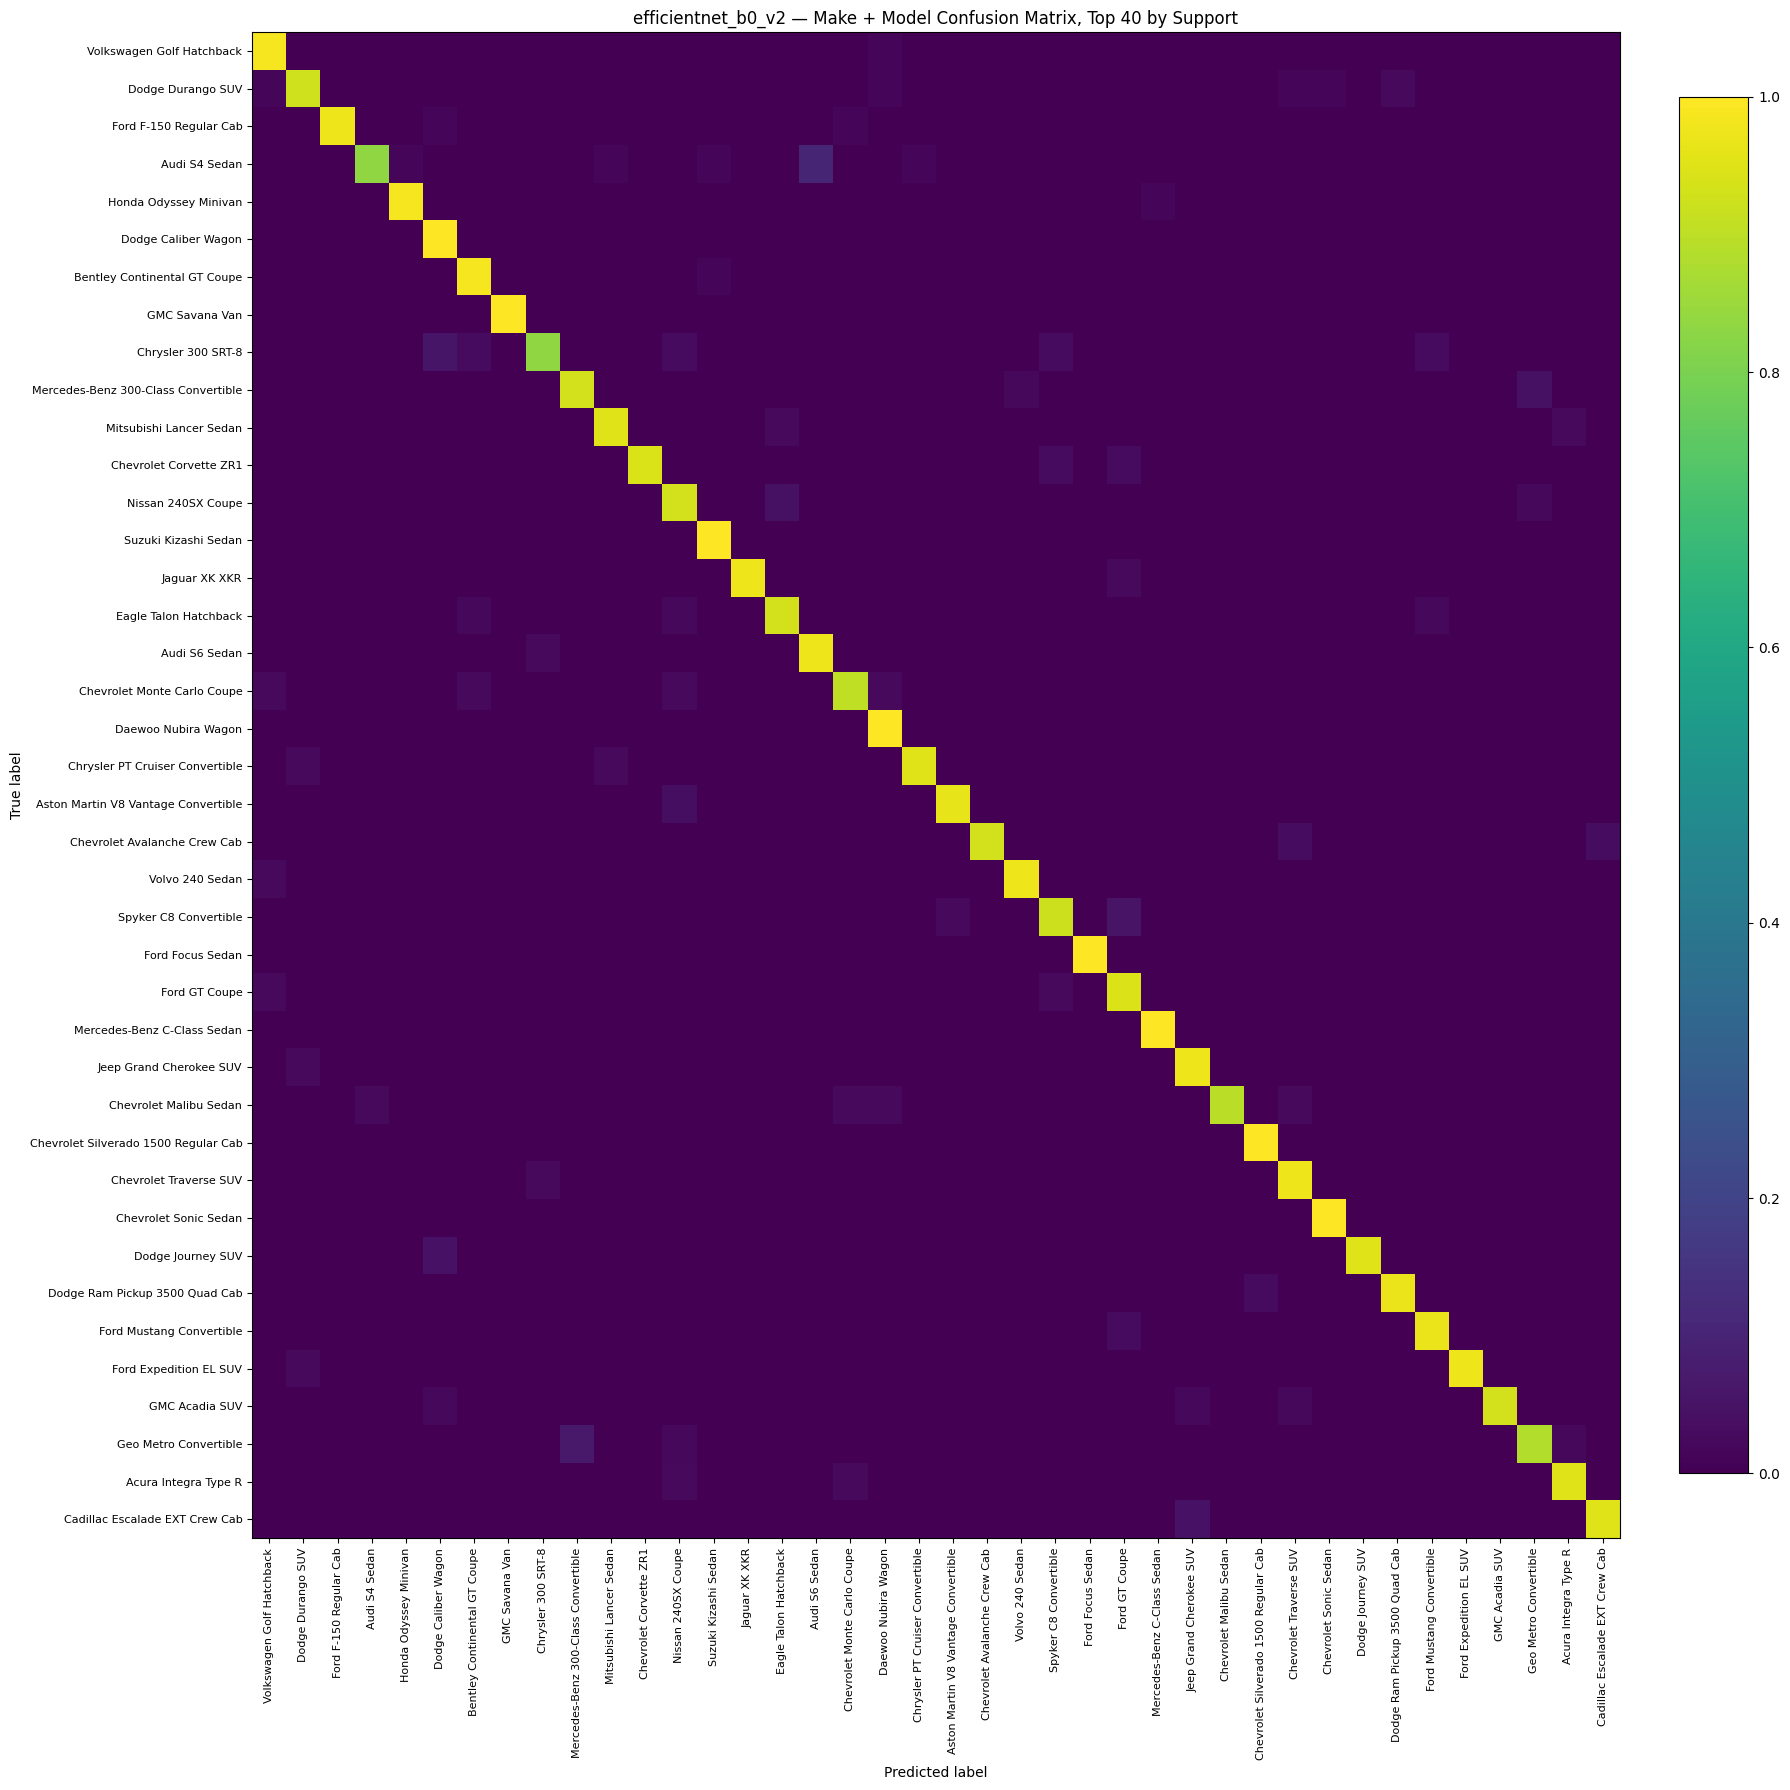

Saved confusion matrix plot to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confusion_matrix_make_model_top.png


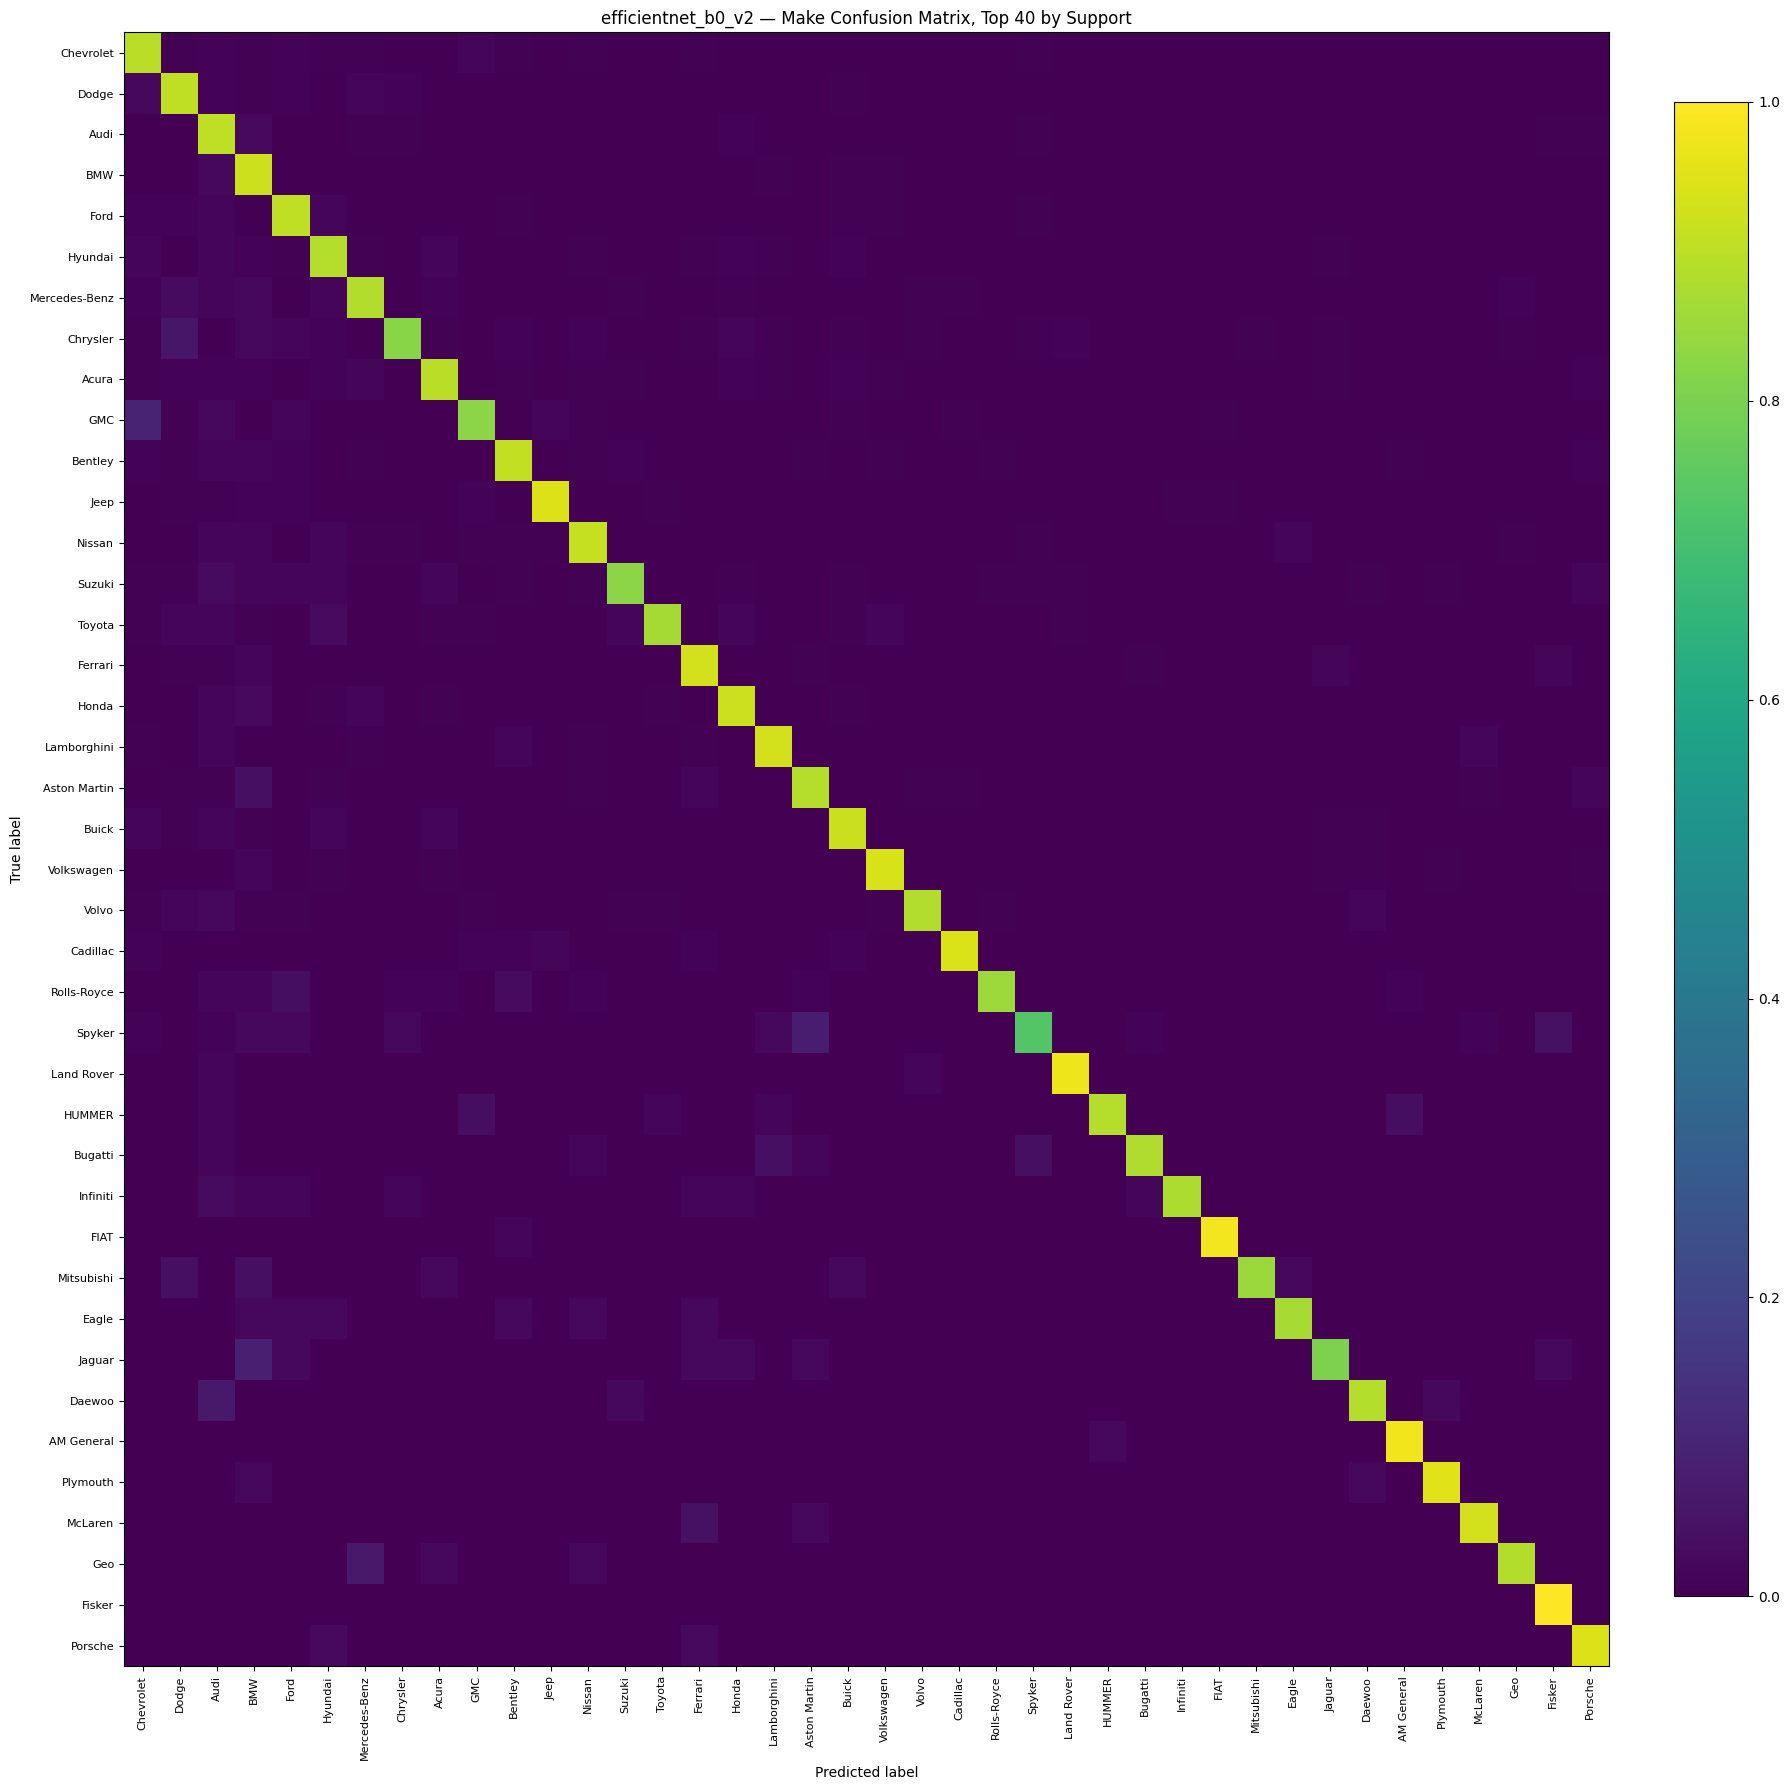

Saved confusion matrix plot to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confusion_matrix_make_top.png
Saved confusion matrix CSV files:
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confusion_matrix_exact_class_full.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confusion_matrix_make_model_full.csv
- /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confusion_matrix_make_full.csv


In [ ]:
def save_confusion_matrix_csv(y_true_labels, y_pred_labels, labels, output_path):
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(output_path)
    return cm_df


def plot_confusion_matrix_top_labels(y_true_labels, y_pred_labels, title, output_path, max_labels=30):
    y_true_series = pd.Series(y_true_labels)
    top_labels = y_true_series.value_counts().head(max_labels).index.tolist()

    # Keep rows where the true label is in the top labels.
    mask = y_true_series.isin(top_labels).to_numpy()
    true_filtered = np.array(y_true_labels)[mask]
    pred_filtered = np.array(y_pred_labels)[mask]

    cm = confusion_matrix(true_filtered, pred_filtered, labels=top_labels)
    cm_normalized = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig_width = max(10, len(top_labels) * 0.45)
    fig_height = max(8, len(top_labels) * 0.45)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    im = ax.imshow(cm_normalized, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks(range(len(top_labels)))
    ax.set_yticks(range(len(top_labels)))
    ax.set_xticklabels(top_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(top_labels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

    print('Saved confusion matrix plot to:', output_path)

# Exact class full CSV
exact_labels = [clean_class_name(idx_to_class[i]) for i in range(num_classes)]
exact_cm_path = REPORTS_DIR / 'confusion_matrix_exact_class_full.csv'
exact_cm_df = save_confusion_matrix_csv(
    [clean_class_name(idx_to_class[int(i)]) for i in y_true],
    [clean_class_name(idx_to_class[int(i)]) for i in y_pred],
    exact_labels,
    exact_cm_path,
)

# Make + model full CSV and readable top-label plot
make_model_labels = sorted(set(predictions_df['true_make_model']) | set(predictions_df['pred_make_model']))
make_model_cm_path = REPORTS_DIR / 'confusion_matrix_make_model_full.csv'
make_model_cm_df = save_confusion_matrix_csv(
    predictions_df['true_make_model'],
    predictions_df['pred_make_model'],
    make_model_labels,
    make_model_cm_path,
)

plot_confusion_matrix_top_labels(
    predictions_df['true_make_model'],
    predictions_df['pred_make_model'],
    title=f'{MODEL_NAME} — Make + Model Confusion Matrix, Top {MAX_LABELS_IN_CONFUSION_MATRIX} by Support',
    output_path=REPORTS_DIR / 'confusion_matrix_make_model_top.png',
    max_labels=MAX_LABELS_IN_CONFUSION_MATRIX,
)

# Make full CSV and readable top-label plot
make_labels = sorted(set(predictions_df['true_make']) | set(predictions_df['pred_make']))
make_cm_path = REPORTS_DIR / 'confusion_matrix_make_full.csv'
make_cm_df = save_confusion_matrix_csv(
    predictions_df['true_make'],
    predictions_df['pred_make'],
    make_labels,
    make_cm_path,
)

plot_confusion_matrix_top_labels(
    predictions_df['true_make'],
    predictions_df['pred_make'],
    title=f'{MODEL_NAME} — Make Confusion Matrix, Top {MAX_LABELS_IN_CONFUSION_MATRIX} by Support',
    output_path=REPORTS_DIR / 'confusion_matrix_make_top.png',
    max_labels=MAX_LABELS_IN_CONFUSION_MATRIX,
)

print('Saved confusion matrix CSV files:')
print('-', exact_cm_path)
print('-', make_model_cm_path)
print('-', make_cm_path)


## Top confusion pairs

This is often more useful than a large confusion matrix.

It answers:

> Which labels does the model most often confuse?


In [ ]:
def top_confusion_pairs(df, true_col, pred_col, level_name, top_n=30):
    wrong = df[df[true_col] != df[pred_col]].copy()
    if wrong.empty:
        return pd.DataFrame(columns=[f'true_{level_name}', f'pred_{level_name}', 'count'])

    result = (
        wrong
        .groupby([true_col, pred_col])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(top_n)
        .rename(columns={true_col: f'true_{level_name}', pred_col: f'pred_{level_name}'})
        .reset_index(drop=True)
    )
    return result

exact_confusions = top_confusion_pairs(predictions_df, 'true_class', 'pred_class', 'class')
make_model_confusions = top_confusion_pairs(predictions_df, 'true_make_model', 'pred_make_model', 'make_model')
make_confusions = top_confusion_pairs(predictions_df, 'true_make', 'pred_make', 'make')

exact_confusions.to_csv(REPORTS_DIR / 'top_confusions_exact_class.csv', index=False)
make_model_confusions.to_csv(REPORTS_DIR / 'top_confusions_make_model.csv', index=False)
make_confusions.to_csv(REPORTS_DIR / 'top_confusions_make.csv', index=False)

print('Top exact-class confusions:')
display(exact_confusions.head(15))

print('Top make + model confusions:')
display(make_model_confusions.head(15))

print('Top make confusions:')
display(make_confusions.head(15))


Top exact-class confusions:


,true_class,pred_class,count
0,Chevrolet Express Van 2007,Chevrolet Express Cargo Van 2007,17
1,Bentley Continental GT Coupe 2007,Bentley Continental GT Coupe 2012,12
2,Chevrolet Silverado 1500 Hybrid Crew Cab 2012,Chevrolet Silverado 1500 Extended Cab 2012,11
3,BMW 6 Series Convertible 2007,BMW M6 Convertible 2010,10
4,Ferrari 458 Italia Convertible 2012,Ferrari 458 Italia Coupe 2012,10
5,Audi S5 Coupe 2012,Audi A5 Coupe 2012,10
6,Dodge Caliber Wagon 2012,Dodge Caliber Wagon 2007,10
7,Audi TTS Coupe 2012,Audi TT Hatchback 2011,9
8,Audi V8 Sedan 1994,Audi 100 Sedan 1994,9
9,Dodge Sprinter Cargo Van 2009,Mercedes-Benz Sprinter Van 2012,9


Top make + model confusions:


,true_make_model,pred_make_model,count
0,Chevrolet Express Van,Chevrolet Express Cargo Van,17
1,Chevrolet Silverado 1500 Hybrid Crew Cab,Chevrolet Silverado 1500 Extended Cab,11
2,BMW 6 Series Convertible,BMW M6 Convertible,10
3,Audi S5 Coupe,Audi A5 Coupe,10
4,Ferrari 458 Italia Convertible,Ferrari 458 Italia Coupe,10
5,Audi V8 Sedan,Audi 100 Sedan,9
6,Audi TTS Coupe,Audi TT Hatchback,9
7,Dodge Sprinter Cargo Van,Mercedes-Benz Sprinter Van,9
8,Bentley Continental Flying Spur Sedan,Bentley Continental GT Coupe,9
9,HUMMER H2 SUT Crew Cab,HUMMER H3T Crew Cab,8


Top make confusions:


,true_make,pred_make,count
0,GMC,Chevrolet,23
1,Chrysler,Dodge,15
2,Audi,BMW,15
3,Dodge,Chevrolet,13
4,Chevrolet,GMC,12
5,BMW,Audi,11
6,Hyundai,Tesla,11
7,Dodge,Mercedes-Benz,11
8,Ford,Hyundai,9
9,Chevrolet,Audi,8


## Confidence and error analysis

This helps answer:

- Is the model confidently wrong?
- Are wrong predictions usually low-confidence?
- Can confidence be used to flag uncertain predictions for human review?

For a real TwinCar system, low-confidence predictions could be sent to manual inspection instead of being trusted automatically.


,correct_exact,count,mean,median,min,max
0,wrong,1469,0.290347,0.205322,0.026260,0.994141
1,correct,6531,0.675568,0.755371,0.038635,0.997070


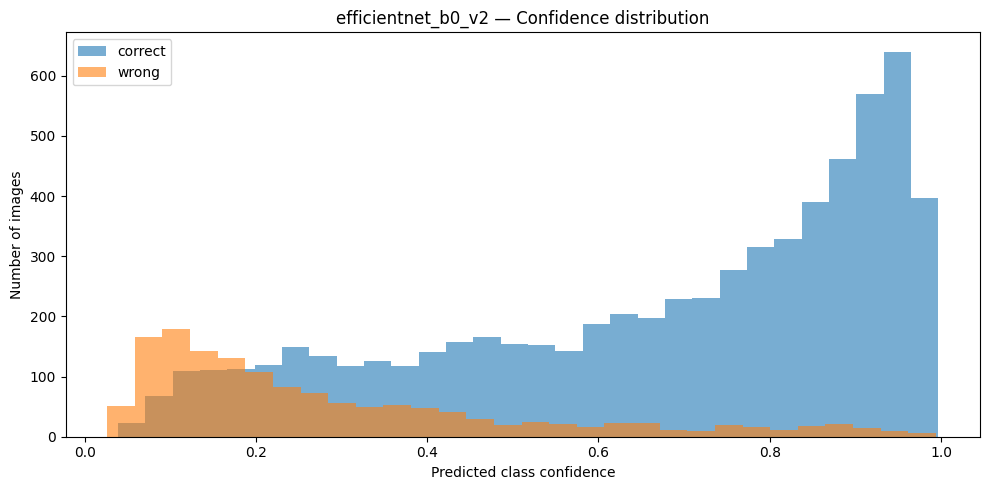

Saved confidence plot to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/confidence_distribution.png


In [ ]:
confidence_summary = predictions_df.groupby('correct_exact')['confidence'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()
confidence_summary['correct_exact'] = confidence_summary['correct_exact'].map({True: 'correct', False: 'wrong'})
confidence_summary_path = REPORTS_DIR / 'confidence_summary.csv'
confidence_summary.to_csv(confidence_summary_path, index=False)

display(confidence_summary)

plt.figure(figsize=(10, 5))
plt.hist(predictions_df.loc[predictions_df['correct_exact'], 'confidence'], bins=30, alpha=0.6, label='correct')
plt.hist(predictions_df.loc[~predictions_df['correct_exact'], 'confidence'], bins=30, alpha=0.6, label='wrong')
plt.title(f'{MODEL_NAME} — Confidence distribution')
plt.xlabel('Predicted class confidence')
plt.ylabel('Number of images')
plt.legend()
plt.tight_layout()
confidence_plot_path = REPORTS_DIR / 'confidence_distribution.png'
plt.savefig(confidence_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved confidence plot to:', confidence_plot_path)


## Visualize misclassified examples

The grid displays high-confidence wrong predictions first, because these are the most interesting mistakes.


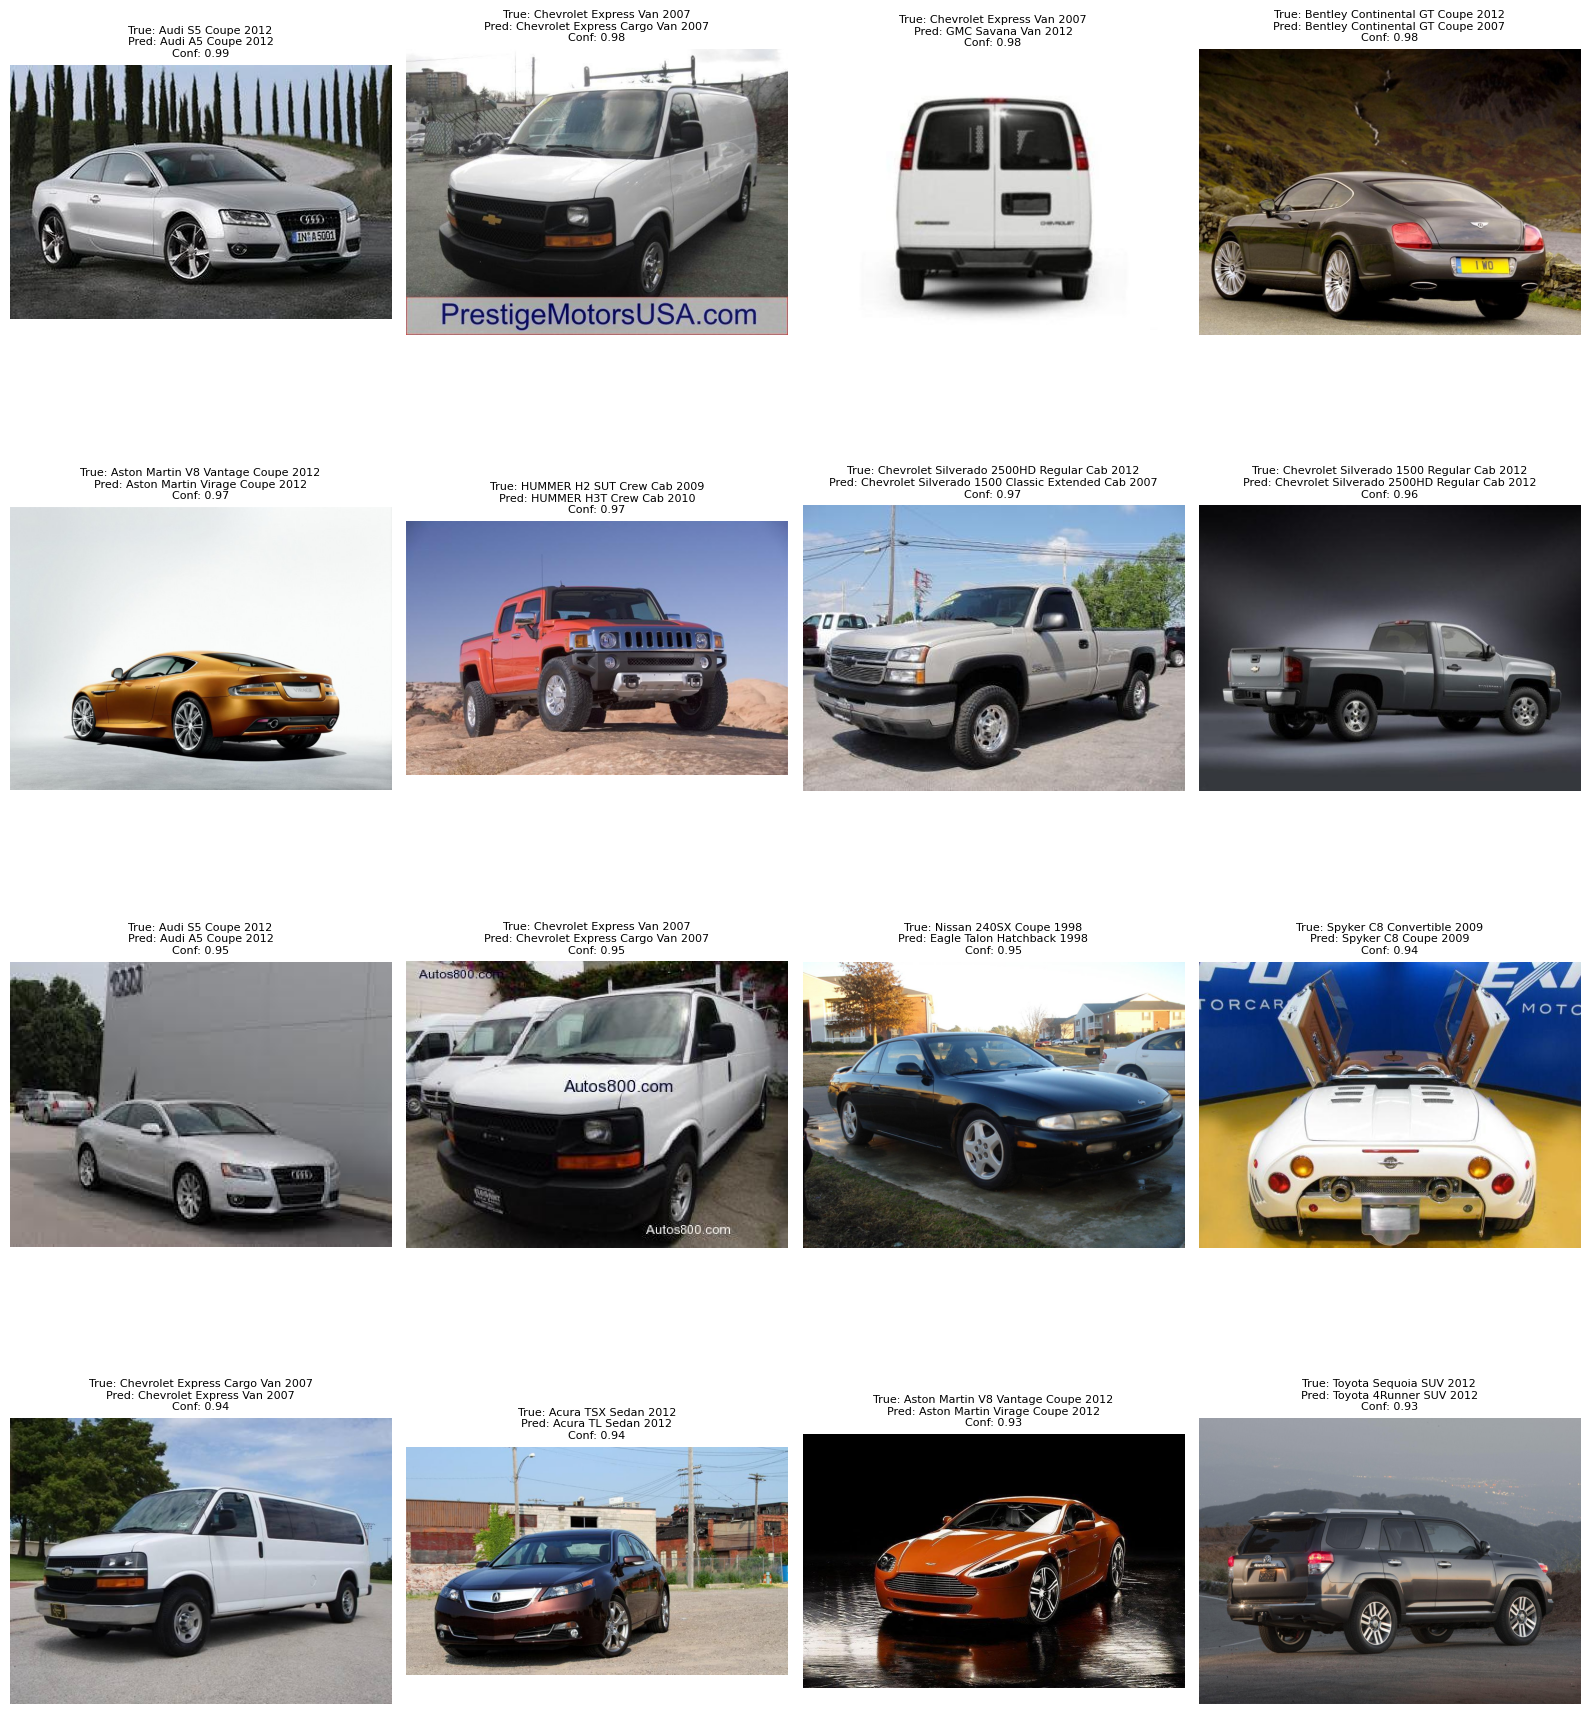

Saved misclassified examples to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/misclassified_examples.png


In [ ]:
from PIL import Image


def show_misclassified_examples(df, n=16, sort_by='confidence'):
    wrong = df[~df['correct_exact']].copy()
    if wrong.empty:
        print('No misclassified examples found.')
        return

    wrong = wrong.sort_values(sort_by, ascending=False).head(n)

    n_cols = 4
    n_rows = int(np.ceil(len(wrong) / n_cols))
    plt.figure(figsize=(4 * n_cols, 4.8 * n_rows))

    for plot_idx, (_, row) in enumerate(wrong.iterrows(), start=1):
        img = Image.open(row['image_path']).convert('RGB')
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        ax.imshow(img)
        ax.axis('off')
        title = (
            f"True: {row['true_class']}\n"
            f"Pred: {row['pred_class']}\n"
            f"Conf: {row['confidence']:.2f}"
        )
        ax.set_title(title, fontsize=8)

    plt.tight_layout()
    output_path = REPORTS_DIR / 'misclassified_examples.png'
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved misclassified examples to:', output_path)

show_misclassified_examples(predictions_df, n=16)


## Training curves from history file


Loaded history: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/training_history.csv


,epoch,train_loss,val_loss,train_top1,val_top1,val_top5,backbone_lr,head_lr
0,1,4.940531,4.445114,0.084652,0.148026,0.390625,0.0001,0.0003
1,2,3.618297,3.257951,0.343546,0.360197,0.682566,0.0001,0.0003
2,3,2.566376,2.655801,0.595034,0.513158,0.821546,0.0001,0.0003
3,4,1.991202,2.278505,0.751561,0.608553,0.875000,0.0001,0.0003
4,5,1.678463,2.108021,0.833890,0.663651,0.895559,0.0001,0.0003


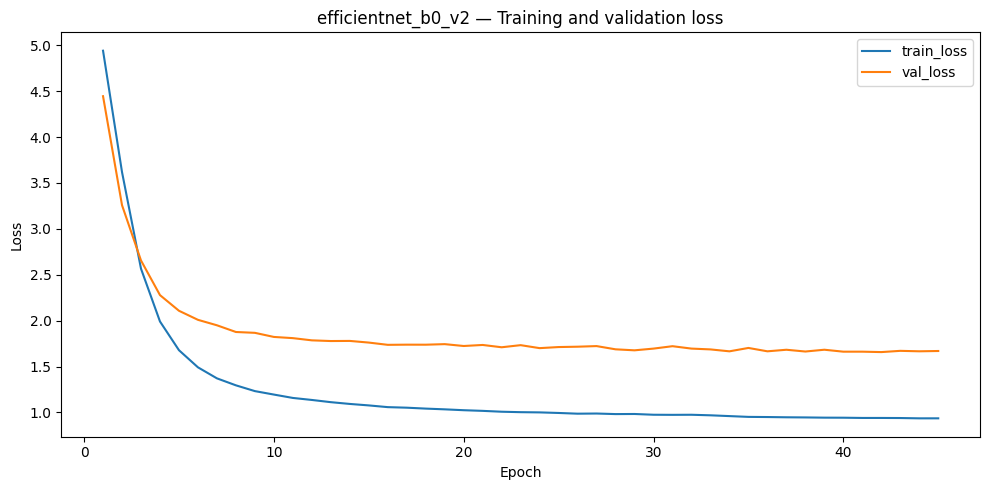

Saved loss curves to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/loss_curves.png


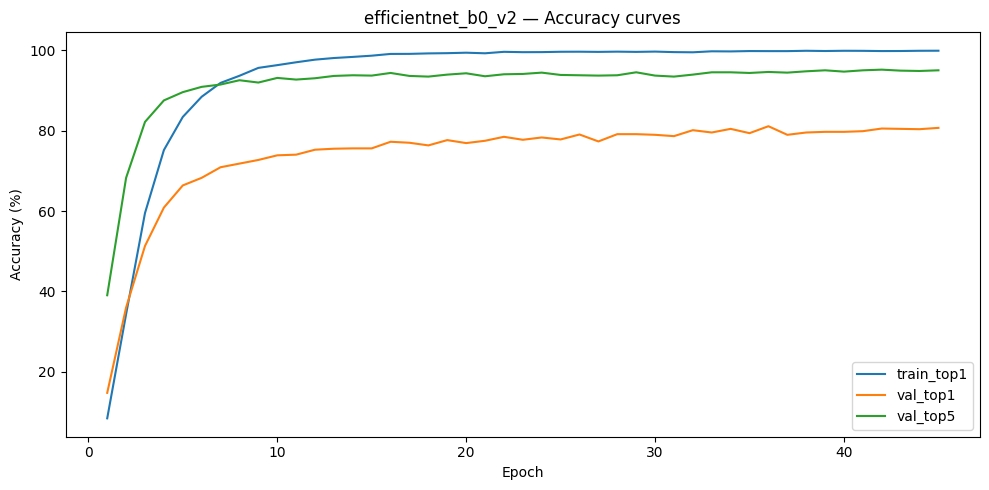

Saved accuracy curves to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/accuracy_curves.png


In [ ]:
possible_history_paths = [
    MODEL_DIR / 'training_history.csv',
    MODEL_DIR / 'history.csv',
    PROJECT_DIR / 'models' / MODEL_NAME / 'training_history.csv',
]

history_path = next((p for p in possible_history_paths if p.exists()), None)

if history_path is None:
    print('No training history CSV found. Skipping training curve plot.')
    print('Expected one of:')
    for p in possible_history_paths:
        print('-', p)
else:
    history_df = pd.read_csv(history_path)
    print('Loaded history:', history_path)
    display(history_df.head())

    # Try to automatically find common column names.
    epoch_col = 'epoch' if 'epoch' in history_df.columns else None
    x = history_df[epoch_col] if epoch_col else np.arange(1, len(history_df) + 1)

    plt.figure(figsize=(10, 5))
    for col in ['train_loss', 'val_loss']:
        if col in history_df.columns:
            plt.plot(x, history_df[col], label=col)
    plt.title(f'{MODEL_NAME} - Training and validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    loss_curve_path = REPORTS_DIR / 'loss_curves.png'
    plt.savefig(loss_curve_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved loss curves to:', loss_curve_path)

    plt.figure(figsize=(10, 5))
    for col in ['train_top1', 'val_top1', 'val_top5', 'train_acc', 'val_acc']:
        if col in history_df.columns:
            values = history_df[col]
            if values.max() <= 1.0:
                values = values * 100
            plt.plot(x, values, label=col)
    plt.title(f'{MODEL_NAME} — Accuracy curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    accuracy_curve_path = REPORTS_DIR / 'accuracy_curves.png'
    plt.savefig(accuracy_curve_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved accuracy curves to:', accuracy_curve_path)


## Summary

The model was evaluated on the held-out test set. We report exact class metrics, but also aggregate by make and make + model to make the results easier to interpret. The make + model metric is especially relevant because identifying the vehicle make and model is the mandatory TwinCar goal.


In [ ]:
final_summary = {
    'model_name': MODEL_NAME,
    'checkpoint_name': CHECKPOINT_NAME,
    'checkpoint_path': str(MODEL_PATH),
    'test_images': len(predictions_df),
    'exact_classes': num_classes,
    'exact_top1_accuracy': metrics['exact_top1_accuracy'],
    'exact_top5_accuracy': metrics['exact_top5_accuracy'],
    'exact_macro_precision': metrics['exact_precision_macro'],
    'exact_macro_recall': metrics['exact_recall_macro'],
    'exact_macro_f1': metrics['exact_f1_macro'],
    'exact_weighted_f1': metrics['exact_f1_weighted'],
    'make_model_accuracy': metrics['make_model_accuracy'],
    'make_accuracy': metrics['make_accuracy'],
    'test_loss': metrics['test_loss'],
    'model_file_size_mb': metrics['model_file_size_mb'],
    'images_per_second_full_eval': metrics['images_per_second'],
}

final_summary_df = pd.DataFrame([final_summary])
final_summary_path = REPORTS_DIR / 'final_readme_summary.csv'
final_summary_df.to_csv(final_summary_path, index=False)

display(final_summary_df.T.rename(columns={0: 'value'}))

print('Saved final summary to:', final_summary_path)
print('\nAll evaluation files were saved in:')
print(REPORTS_DIR)


,value
model_name,efficientnet_b0_v2
checkpoint_name,best_model
checkpoint_path,/content/drive/MyDrive/twincar/models/efficien...
test_images,8000
exact_classes,195
exact_top1_accuracy,0.816375
exact_top5_accuracy,0.945
exact_macro_precision,0.829661
exact_macro_recall,0.816341
exact_macro_f1,0.817611


Saved final summary to: /content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation/final_readme_summary.csv

All evaluation files were saved in:
/content/drive/MyDrive/twincar/reports/efficientnet_b0_v2_best_model_evaluation
